
**<center><font size=6>Hands-on: Sentiment Analysis with Word Embeddings and Transformers</center></font>**

<div style="text-align: center;">
    <img
        src="https://github.com/ajayvdatascience/image/blob/main/9d3a5a06-bf32-4a05-95aa-df14bbd68f33.png?raw=true"
        alt=""
        style="width: 100%; max-width: 1200px; height: auto;"
    >
</div>

# **Problem Statement**

* The entertainment industry receives a **large volume of movie reviews** from audiences across different platforms.
* Manually analyzing these reviews is **time-consuming and inefficient**.
* It is difficult to identify overall **positive, negative, or neutral sentiments** from thousands of reviews.
* Traditional manual methods may **miss subtle or nuanced emotions** expressed by viewers.
* Businesses need **fast and automated sentiment analysis** to understand audience reactions.
* Lack of timely sentiment insights can make it difficult to **improve marketing and promotional strategies**.
* Movie producers can struggle to identify **audience preferences and areas for improvement**.
* An AI-based system can automatically **process and classify movie reviews based on sentiment**.
* The system can summarize audience opinions and provide **actionable insights**.
* This helps stakeholders make **data-driven decisions** and improve the overall viewer experience.


# **Installing and Importing Necessary Libraries**

| Library / Package         | Name                                      | Purpose                                                          |
| ------------------------- | ----------------------------------------- | ---------------------------------------------------------------- |
| **NumPy**                 | `numpy`                                   | Numerical computations and array operations                      |
| **Pandas**                | `pandas`                                  | Reading, cleaning, manipulating, and analyzing data              |
| **Matplotlib**            | `matplotlib.pyplot`                       | Creating data visualizations and graphs                          |
| **Seaborn**               | `seaborn`                                 | Statistical data visualization                                   |
| **Gensim**                | `gensim.models.Word2Vec`                  | Creating **Word2Vec word embeddings**                            |
| **Sentence Transformers** | `sentence_transformers`                   | Converting text into **semantic sentence embeddings**            |
| **Scikit-learn**          | `sklearn`                                 | Machine learning, data splitting, classification, and evaluation |
| **Random Forest**         | `sklearn.ensemble.RandomForestClassifier` | Building the **Random Forest classification model**              |
| **TensorFlow**            | `tensorflow`                              | Deep learning and neural network development                     |
| **Keras**                 | `tensorflow.keras`                        | Building and training deep learning models                       |
| **Warnings**              | `warnings`                                | Suppressing unnecessary warning messages                         |


In [ ]:
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2\
             accelerate==1.7.0\
             sentencepiece==0.2.0

In [ ]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
#import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
#from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# **Importing the dataset**

In [ ]:
# uncomment and run the following line if using Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# loading data into a pandas dataframe
reviews = pd.read_csv("/content/drive/MyDrive/GEN AI DATASET/movie_review.csv")

In [ ]:
# creating a copy of the data
data = reviews.copy()

# **Data Overview**

**Checking the first 5 rows**

In [ ]:
data.head(5)

,review,sentiment
0,"Okay, I know this does'nt project India in a good light. But the overall theme of the movie is not India, it's Shakti. The power of a warlord, and the power of a mother. The relationship between Nandini and her husband and son swallow you up in their warmth. Then things go terribly wrong. The interaction between Nandini and her father in law - the power of their dysfunctional relationship - and the lives changed by it are the strengths of this movie. Shah Rukh Khan's performance seems to be a mere cameo compared to the believable desperation of Karisma Kapoor. It is easy to get caught up in the love, violence and redemption of lives in this film, and find yourself heaving a sigh of relief and sadness at the climax. The musical interludes are strengths, believable and well done.",1
1,"Despite John Travolta's statements in interviews that this was his favorite role of his career, ""Be Cool"" proves to be a disappointing sequel to 1995's witty and clever ""Get Shorty.""<br /><br />Travolta delivers a pleasant enough performance in this mildly entertaining film, but ultimately the movie falls flat due to an underdeveloped plot, unlikeable characters, and a surprising lack of chemistry between leads Travolta and Uma Thurman. Although there are some laughs, this unfunny dialog example (which appeared frequently in the trailers) kind of says it all: Thurman: Do you dance? Travolta: Hey, I'm from Brooklyn.<br /><br />The film suggests that everyone in the entertainment business is a gangster or aspires to be one, likening it to organized crime. In ""Get Shorty,"" the premise of a gangster ""going legitimate"" by getting into movies was a clever fish-out-of water idea, but in ""Be Cool,"" it seems the biz has entirely gone crooked since then.<br /><br />The film is interestingly casted and the absolute highlight is a ""monolgue"" delivered by The Rock, whose character is an aspiring actor as well as a goon, where he reenacts a scene between Gabrielle Union and Kirsten Dunst from ""Bring It On."" Vince Vaughan's character thinks he's black and he's often seen dressed as a pimp-- this was quite funny in the first scene that introduces him and gets tired and embarrassing almost immediately afterward.<br /><br />Overall, ""Be Cool"" may be worth a rental for John Travolta die-hards (of which I am one), but you may want to keep your finger close to the fast forward button to get through it without feeling that you wasted too much time. Fans of ""Get Shorty"" may actually wish to avoid this, as the sequel is devoid of most things that made that one a winner. I rate this movie an admittedly harsh 4/10.",0
2,"I am a kung fu fan, but not a Woo fan. I have no interest in gangster movies filled with over-the-top gun-play. Now, martial arts; *that's* beautiful! And John Woo surprised me here by producing a highly entertaining kung fu movie, which almost has *too much* fighting, if such a thing is possible! This is good stuff.<br /><br />Many of the fight scenes are very good (and some of them are less good), and the main characters are amusing and likable. The bad guys are a bit too unbelievably evil, but entertaining none the less. You gotta see the Sleeping Wizard!! He can only fight when he's asleep - it's hysterical!<br /><br />Upon repeated viewings, however, Last Hurrah For Chivalry can tend to get a little boring and long-winded, also especially because many of the fight scenes are actually not that good. Hence, I rate it ""only"" a 7 out of 10. But it really is almost an ""8"".<br /><br />All in all one of the better kung fu movies, made smack-dab in the heart of kung fu cinema's prime. All the really good kung fu movies are from the mid- to late 1970ies, with some notable exceptions from the late '60ies and early '70ies (and early '80ies, to be fair).",1
3,"He seems to be a control freak. I have heard him comment on ""losing control of the show"" and tell another guest who brought live animals that he had one rule-""n

* Here, a sentiment value of **0 is negative** and **1 is positive**.

**Checking the shape of the data**

In [ ]:
data.shape

(9982, 2)

* The dataset has 10000 rows and 2 columns.

**Checking for missing values**

In [ ]:
data.isnull().sum()

,0
review,0
sentiment,0


* There are no missing values in the data

**Checking for duplicate values**

In [ ]:
# checking for duplicate values
data.duplicated().sum()

0

In [ ]:
# keeping only the first occurence of duplicate values and dropping the rest
data = data.drop_duplicates(keep = 'first')

In [ ]:
# reseting the index of the dataframe
data = data.reset_index(drop = True)

In [ ]:
data

,review,sentiment
0,"Okay, I know this does'nt project India in a good light. But the overall theme of the movie is not India, it's Shakti. The power of a warlord, and the power of a mother. The relationship between Nandini and her husband and son swallow you up in their warmth. Then things go terribly wrong. The interaction between Nandini and her father in law - the power of their dysfunctional relationship - and the lives changed by it are the strengths of this movie. Shah Rukh Khan's performance seems to be a mere cameo compared to the believable desperation of Karisma Kapoor. It is easy to get caught up in the love, violence and redemption of lives in this film, and find yourself heaving a sigh of relief and sadness at the climax. The musical interludes are strengths, believable and well done.",1
1,"Despite John Travolta's statements in interviews that this was his favorite role of his career, ""Be Cool"" proves to be a disappointing sequel to 1995's witty and clever ""Get Shorty.""<br /><br />Travolta delivers a pleasant enough performance in this mildly entertaining film, but ultimately the movie falls flat due to an underdeveloped plot, unlikeable characters, and a surprising lack of chemistry between leads Travolta and Uma Thurman. Although there are some laughs, this unfunny dialog example (which appeared frequently in the trailers) kind of says it all: Thurman: Do you dance? Travolta: Hey, I'm from Brooklyn.<br /><br />The film suggests that everyone in the entertainment business is a gangster or aspires to be one, likening it to organized crime. In ""Get Shorty,"" the premise of a gangster ""going legitimate"" by getting into movies was a clever fish-out-of water idea, but in ""Be Cool,"" it seems the biz has entirely gone crooked since then.<br /><br />The film is interestingly casted and the absolute highlight is a ""monolgue"" delivered by The Rock, whose character is an aspiring actor as well as a goon, where he reenacts a scene between Gabrielle Union and Kirsten Dunst from ""Bring It On."" Vince Vaughan's character thinks he's black and he's often seen dressed as a pimp-- this was quite funny in the first scene that introduces him and gets tired and embarrassing almost immediately afterward.<br /><br />Overall, ""Be Cool"" may be worth a rental for John Travolta die-hards (of which I am one), but you may want to keep your finger close to the fast forward button to get through it without feeling that you wasted too much time. Fans of ""Get Shorty"" may actually wish to avoid this, as the sequel is devoid of most things that made that one a winner. I rate this movie an admittedly harsh 4/10.",0
2,"I am a kung fu fan, but not a Woo fan. I have no interest in gangster movies filled with over-the-top gun-play. Now, martial arts; *that's* beautiful! And John Woo surprised me here by producing a highly entertaining kung fu movie, which almost has *too much* fighting, if such a thing is possible! This is good stuff.<br /><br />Many of the fight scenes are very good (and some of them are less good), and the main characters are amusing and likable. The bad guys are a bit too unbelievably evil, but entertaining none the less. You gotta see the Sleeping Wizard!! He can only fight when he's asleep - it's hysterical!<br /><br />Upon repeated viewings, however, Last Hurrah For Chivalry can tend to get a little boring and long-winded, also especially because many of the fight scenes are actually not that good. Hence, I rate it ""only"" a 7 out of 10. But it really is almost an ""8"".<br /><br />All in all one of the better kung fu movies, made smack-dab in the heart of kung fu cinema's prime. All the really good kung fu movies are from the mid- to late 1970ies, with some notable exceptions from the late '60ies and early '70ies (and early '80ies, to be fair).",1
3,"He seems to be a control freak. I have heard him comment on ""losing control of the show"" and tell another guest who brought live animals that he had one rule-""n

## **Checking the distribution of sentiments**

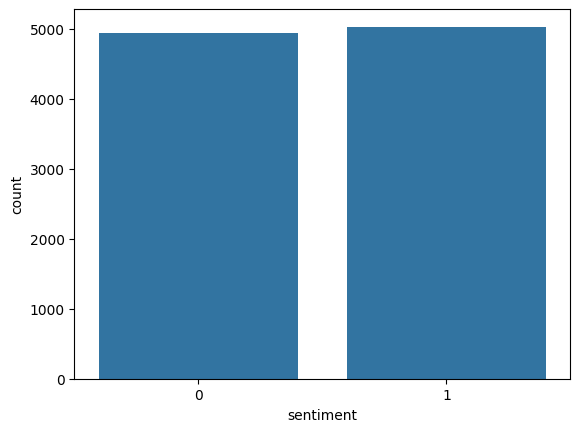

In [ ]:
sns.countplot(data=data, x='sentiment');

- There are almost an equal number of positive and negative reviews.

# **Text Embedding and Sentiment Analysis: Word2Vec**

## **Generating Embeddings with Word2Vec**

• Word2Vec is a popular word embedding technique used to convert words into numerical vectors.

• It is imported from the Gensim library using the Word2Vec class.

• Word2Vec represents words based on their meaning and relationship with other words in the given text.

• Words that appear in similar contexts are represented by vectors that are closer to each other.

• Word2Vec is commonly used in Natural Language Processing (NLP) applications such as sentiment analysis, text classification, recommendation systems, and document similarity.


**Default Setting :**

• By default, Word2Vec creates word vectors with a vector size of 100 dimensions.

• The vector size can be changed according to the requirements of the project.

• The trained word vectors can then be used as input features for machine learning models.

In [ ]:
# Creating a list of all words in our data
words_list = [item.split(" ") for item in data['review'].values]

In [ ]:
len(words_list)

9982

In [ ]:
# Creating an instance of Word2Vec
vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 1, window=5, workers = 6)

In [ ]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(list(model_W2V.wv.key_to_index)))

Length of the vocabulary is 157460


### **Basic Examples**

**Word2Vec – Good**

• model_W2V.wv["good"] returns the word vector for "good".

• It represents the word good as a numerical vector.

• If vector_size=5, the word is represented using 5 numerical values.

In [ ]:
model_W2V.wv["good"]

array([ 0.8630688 ,  0.9011284 , -0.01130298,  0.7879173 ,  0.14802769,
       -1.8242078 ,  2.1219065 ,  0.6277313 , -0.6747091 , -0.46843693,
        0.2683401 , -1.7125591 , -0.73872155,  0.423358  , -0.9250204 ,
        0.07152313, -0.27200598, -0.52171266, -0.31592104, -1.0644407 ,
        0.4281843 ,  0.1293383 ,  0.11142921,  1.5785105 , -0.8928587 ,
       -0.88389105, -0.03031001, -0.90697724, -1.4381448 , -1.5220468 ,
        1.2866449 , -0.5337475 ,  0.3272708 ,  1.4018761 ,  0.8248221 ,
       -1.156926  ,  0.814536  , -0.1388757 ,  0.97079045,  0.23514315,
        0.23913568, -0.5071164 ,  0.05315349,  0.3285881 ,  1.0807709 ,
       -0.5238058 , -0.33010626,  1.1253698 ,  0.2671194 ,  0.38751113,
       -0.39588037, -0.34678546,  0.85920906, -0.72396934, -0.22744267,
        0.0202646 ,  1.5423691 , -1.2844781 ,  1.1195889 , -0.8376486 ,
       -0.43557692,  0.35850132, -0.3341192 , -0.9678146 ,  0.07864863,
        0.28306615, -0.16871104, -0.17979807,  0.5217565 , -0.03

**Word2Vec – Bad**

• model_W2V.wv["bad"] returns the word vector for "bad".

• It represents the word bad as a numerical vector.

• If vector_size=5, the word is represented using 5 numerical values.

In [ ]:
model_W2V.wv["best"]

array([-0.08811767,  0.816429  , -0.58139324,  0.03181653,  0.04182883,
       -0.1425538 ,  0.2944737 ,  0.24061956, -1.728323  ,  0.7982336 ,
        0.2180258 , -0.9586312 , -1.3910477 ,  0.84281975, -0.57957494,
        0.31932774,  1.4432921 , -1.3156186 ,  1.0774277 , -0.63409984,
        1.3233486 ,  1.0613296 ,  0.4361119 , -0.38598198,  0.7243528 ,
       -1.4282876 , -0.9042067 ,  0.18363047,  0.5172431 , -2.046701  ,
        0.6697175 ,  1.0469469 , -0.8877767 ,  0.9860449 ,  0.5217893 ,
       -0.4682213 ,  0.3061662 , -0.29987225,  1.0041921 ,  0.17550413,
       -1.0679436 ,  0.676141  ,  0.60546315,  0.78760177,  1.0938056 ,
       -0.4361121 , -1.0108486 ,  0.8677522 ,  0.05235356,  0.86417425,
       -0.58390826,  1.1466128 ,  0.9451061 ,  0.32465655,  0.7527894 ,
       -1.4244585 ,  0.66770524, -0.9651004 ,  0.8662894 , -0.72841316,
        0.36542156, -1.1288006 , -0.886342  , -1.2350423 , -0.4571351 ,
        0.23552331, -0.12753291, -0.36445367,  0.45518565, -1.33

### **Encoding the dataset**

In [ ]:
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(model_W2V.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = model_W2V.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))

In [ ]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# creating a dataframe of the vectorized documents
df_Word2Vec = pd.DataFrame(data['review'].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
df_Word2Vec.head()

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,...,Feature 290,Feature 291,Feature 292,Feature 293,Feature 294,Feature 295,Feature 296,Feature 297,Feature 298,Feature 299
0,0.207546,-0.171767,-0.141057,-0.081718,0.128168,-0.271266,0.442068,0.719228,0.108441,-0.187707,...,0.016664,0.506528,0.244618,0.072427,0.657947,0.574696,0.011358,-0.395424,0.264080,-0.142221
1,0.142504,0.057928,-0.120974,-0.180328,0.066865,-0.312624,0.508492,0.633095,0.022932,-0.162680,...,0.047528,0.298008,0.087508,-0.037231,0.419021,0.616423,-0.013418,-0.317756,0.237147,-0.291212
2,0.208375,0.014612,-0.155923,0.012078,0.049343,-0.395674,0.443899,0.652490,0.029244,-0.195513,...,-0.011286,0.242970,0.138178,-0.111758,0.471750,0.607750,0.028728,-0.261683,0.247908,-0.296071
3,0.171015,0.042646,-0.051150,-0.221954,0.104522,-0.219124,0.627610,0.588328,0.153112,-0.280055,...,0.040680,0.236360,-0.004124,-0.137735,0.444576,0.701836,0.007233,-0.167884,0.239976,-0.263480
4,0.222833,0.029912,-0.180262,-0.135964,0.045140,-0.317336,0.682229,0.682384,0.154395,-0.223140,...,0.044078,0.218286,0.020653,-0.138557,0.475593,0.720729,0.040678,-0.323776,0.289032,-0.211331


## **Sentiment Analysis with Random Forest**

In [ ]:
# Define a function to plot the confusion matrix
def plot_confusion_matrix(actual, predicted):
    # Calculate the confusion matrix
    cm = confusion_matrix(actual, predicted)

    # Create a figure for the plot
    plt.figure(figsize = (5, 4))
    # Define labels for the plot axes
    label_list = ['negative', 'positive']
    # Create a heatmap of the confusion matrix
    sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = label_list, yticklabels = label_list)
    # Set the y-axis label
    plt.ylabel('Actual')
    # Set the x-axis label
    plt.xlabel('Predicted')
    # Display the plot
    plt.show()

In [ ]:
# Storing independent variable
X = df_Word2Vec.copy()

# Storing target variable
y = data.sentiment

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [ ]:
# Building the model
rf_word2vec = RandomForestClassifier(n_estimators = 100, max_depth = 3, random_state = 42)

# Fitting on train data
rf_word2vec.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

**Observation**

* `df_Word2Vec` is used as the **independent variable (X)** containing Word2Vec-based features.
* `data.sentiment` is used as the **target variable (y)** for sentiment classification.
* `train_test_split()` divides the dataset into **80% training data and 20% testing data**.
* `random_state=42` ensures the same split can be reproduced.
* `plot_confusion_matrix()` calculates and visualizes the model's **actual vs predicted** classifications.
* The confusion matrix uses two classes: **Negative** and **Positive**.
* The heatmap helps identify **correct predictions and classification errors**.


### **Checking Training and Test Performance**

In [ ]:
# Predicting on train data
y_pred_train = rf_word2vec.predict(X_train)

# Predicting on test data
y_pred_test = rf_word2vec.predict(X_test)

**Confusion Matrix**

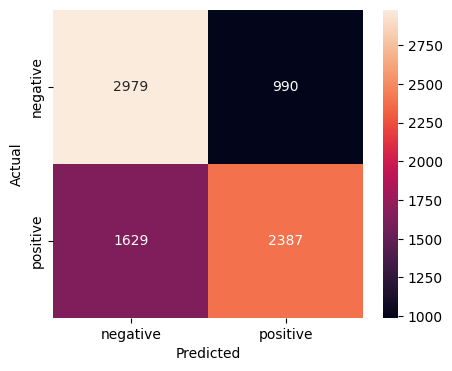

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

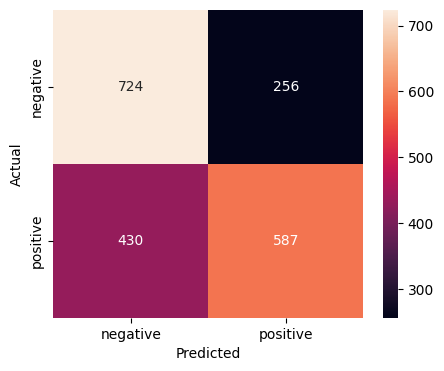

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

**Accuracy**

In [ ]:
train_accuracy_Word2Vec_RF = accuracy_score(y_train,y_pred_train)
print("The accuracy on the training set is: ",train_accuracy_Word2Vec_RF)
test_accuracy_Word2Vec_RF = accuracy_score(y_test,y_pred_test)
print("The accuracy on the test set is: ",test_accuracy_Word2Vec_RF)

The accuracy on the training set is:  0.6720100187852223
The accuracy on the test set is:  0.656484727090636


## **Sentiment Analysis with Neural Networks**

In [ ]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Model definition
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))  # 2 output classes

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since labels are integers
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,914 (183.26 KB)

 Trainable params: 46,914 (183.26 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fitting the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6154 - loss: 0.6500 - val_accuracy: 0.6855 - val_loss: 0.6073
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6788 - loss: 0.5964 - val_accuracy: 0.6830 - val_loss: 0.5923
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6943 - loss: 0.5837 - val_accuracy: 0.6730 - val_loss: 0.6108
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6904 - loss: 0.5859 - val_accuracy: 0.7011 - val_loss: 0.5729
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7007 - loss: 0.5750 - val_accuracy: 0.7191 - val_loss: 0.5583
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7088 - loss: 0.5648 - val_accuracy: 0.6910 - val_loss: 0.6023
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7056 - loss: 0.5664 - val_accuracy: 0.7246 - val_loss: 0.5550
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7062 - loss: 0.5639 - val_accuracy: 0.

**Observation**

* The previous TensorFlow/Keras session is cleared using `clear_session()` to release model resources.
* `gc.collect()` performs garbage collection to free unused memory.
* A **Sequential neural network** is created for sentiment classification.
* The first `Dense` layer contains **128 neurons** with ReLU activation.
* `Dropout(0.3)` randomly drops 30% of neurons during training to help reduce overfitting.
* The second `Dense` layer contains **64 neurons** with ReLU activation.
* The final layer contains **2 neurons** with Softmax activation for **Negative and Positive** sentiment classes.
* The **Adam optimizer** is used to update model weights.
* `sparse_categorical_crossentropy` is used because the sentiment labels are represented as integers.
* **Accuracy** is selected as the evaluation metric.
* `model.summary()` displays the model architecture and number of parameters.


### **Checking Training and Test Performance**

In [ ]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


**Confusion Matrix**

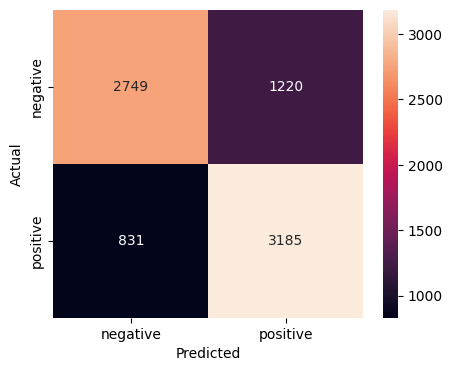

In [ ]:
plot_confusion_matrix(y_train, y_train_preds)

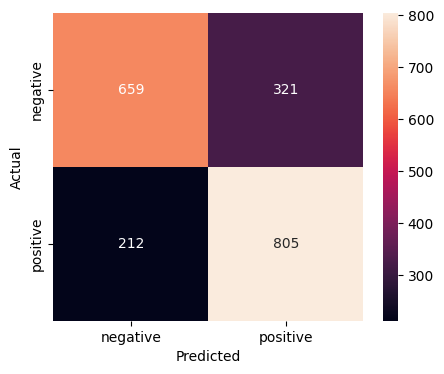

In [ ]:
plot_confusion_matrix(y_test, y_test_preds)

**Accuracy**

In [ ]:
train_accuracy_Word2Vec_NN = accuracy_score(y_train,y_train_preds)
print("The accuracy on the train set is: ",train_accuracy_Word2Vec_NN)
test_accuracy_Word2Vec_NN = accuracy_score(y_test,y_test_preds)
print("The accuracy on the test set is: ",test_accuracy_Word2Vec_NN)

The accuracy on the train set is:  0.743143393863494
The accuracy on the test set is:  0.7330996494742114


# **Text Embedding and Sentiment Analysis: Transformers**

## **Generating Embeddings with Sentence Tranformers**

* The **all-MiniLM-L6-v2** model is selected to generate sentence embeddings.
* It converts text into **384-dimensional numerical vectors**.
* The model uses **6 Transformer encoder layers**.
* These embeddings can be used as input features for tasks such as **sentiment analysis, text classification, and semantic search**.
* In this project, the embeddings are used to represent text numerically before applying the classification model.


In [ ]:
# defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

- There are many other models to choose from too!
- One place to check for the best models is the [HuggingFace leaderboard](https://www.sbert.net/docs/pretrained_models.html).
- Below is an example of another model that one can use in this case.

> `model = SentenceTransformer('BAAI/bge-base-en-v1.5')`

### **Basic Examples**

In [ ]:
model.encode(['Hello, my name is Prof. Zena!'])

array([[-1.01322196e-01,  2.77659651e-02, -4.15140167e-02,
         1.84561331e-02, -4.85775098e-02, -1.63206980e-02,
         1.31670907e-01, -2.84867585e-02,  2.94027105e-03,
        -2.18541548e-02, -5.48136197e-02, -9.36226081e-03,
        -1.48072606e-02,  2.78399605e-02, -3.74657623e-02,
        -4.98651643e-04, -6.98258914e-03, -2.66996603e-02,
        -3.89730930e-02, -2.10851002e-02, -9.75728966e-03,
        -1.97300152e-03,  5.53301498e-02, -3.02358530e-02,
        -7.95633122e-02, -1.13197053e-02, -1.35750854e-02,
         1.47868795e-02, -3.55500705e-03, -7.07181171e-02,
         2.56204475e-02,  6.83853254e-02,  2.18798555e-02,
        -1.32915529e-03,  5.71828224e-02,  5.70111908e-02,
        -6.20051324e-02, -1.44120688e-02,  7.99196865e-03,
         7.58336857e-04,  1.20889815e-03,  6.11671666e-03,
        -8.94941986e-02, -3.09460168e-03, -5.15797921e-02,
        -4.05938737e-02,  6.07262924e-02, -1.10700633e-02,
         6.72289878e-02, -3.69399451e-02, -9.92941856e-0

In [ ]:
model.encode(['Hello, my name is Professor Zena!'])

array([[-1.11282602e-01,  4.16151769e-02, -4.53358889e-02,
         1.95421576e-02, -6.02429882e-02, -3.59271988e-02,
         9.60513577e-02, -5.55648804e-02,  2.31815446e-02,
        -6.68977946e-03, -2.75410060e-02,  9.78378300e-03,
        -4.83657001e-03,  4.17626053e-02, -5.34442291e-02,
        -3.23547050e-04, -1.19966827e-02, -5.33526130e-02,
        -3.72466594e-02,  5.55628678e-03, -4.23140032e-03,
         2.12436840e-02,  4.35178429e-02, -2.97153555e-02,
        -6.82366192e-02,  1.11056603e-02,  1.19564170e-02,
        -3.14616552e-03, -1.08422143e-02, -6.52326345e-02,
         1.06411679e-02,  6.62760437e-02,  7.96016026e-03,
        -1.82570405e-02,  4.55049314e-02,  3.26332897e-02,
        -3.87101732e-02, -6.36683730e-03,  3.26532610e-02,
        -8.85265134e-03,  2.78327568e-03,  2.53109559e-02,
        -6.47957101e-02, -2.17167363e-02, -5.99524081e-02,
        -2.76416708e-02,  6.41192943e-02, -3.19894478e-02,
         8.19110945e-02, -4.25210595e-02, -7.33607784e-0

### **Encoding the dataset**

In [ ]:
# encoding the dataset
embedding_matrix = model.encode(data['review'], show_progress_bar=True)

Batches:   0%|          | 0/312 [00:00<?, ?it/s]

In [ ]:
# printing the shape of the embedding matrix
embedding_matrix.shape

(9982, 384)

In [ ]:
# printing the embedding vector of the first review in the dataset
embedding_matrix[0,:]

array([-7.45214149e-02,  2.59456411e-03, -3.34988907e-02, -4.84162644e-02,
       -3.84775251e-02,  6.37952834e-02,  5.54265268e-03,  4.06936556e-02,
        6.29823580e-02, -3.84879708e-02, -1.27105061e-02, -2.12660301e-02,
        6.79038689e-02,  2.27336353e-03,  1.14880851e-03,  2.30603516e-02,
        8.18005055e-02,  4.14928496e-02, -2.12946702e-02, -2.29654647e-02,
        2.09020432e-02, -2.93925442e-02,  9.37751159e-02, -2.93005202e-02,
       -6.34454638e-02, -1.70641728e-02,  1.12413347e-01, -2.24412419e-02,
       -6.00714348e-02,  1.55951604e-02,  2.08699889e-02,  7.55285397e-02,
       -6.04214668e-02,  2.33692699e-03, -1.79052930e-02,  7.56649822e-02,
        9.78589524e-03,  2.67772693e-02, -1.30182290e-02, -1.76513698e-02,
        3.84344533e-02,  3.93548310e-02,  5.56520447e-02, -1.35076242e-02,
        5.03627956e-02, -7.22084865e-02, -2.37328969e-02, -1.08479731e-01,
        2.67260782e-02, -5.05364686e-02, -8.09637830e-02,  5.58139868e-02,
       -1.44371507e-03, -

**Important Note**
- The model used here is pre-trained and has not been trained or fine-tuned on this specific dataset. As a result, its performance may not be optimal.

## **Sentiment Analysis with Random Forest**

In [ ]:
# Storing independent variable
X = embedding_matrix

# Storing target variable
y = data["sentiment"]

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Building the model
rf_transformer = RandomForestClassifier(n_estimators = 100, max_depth = 3, random_state = 42)

# Fitting on train data
rf_transformer.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

### **Checking Training and Test Performance**

In [ ]:
# Predicting on train data
y_pred_train = rf_transformer.predict(X_train)

# Predicting on test data
y_pred_test = rf_transformer.predict(X_test)

**Confusion Matrix**

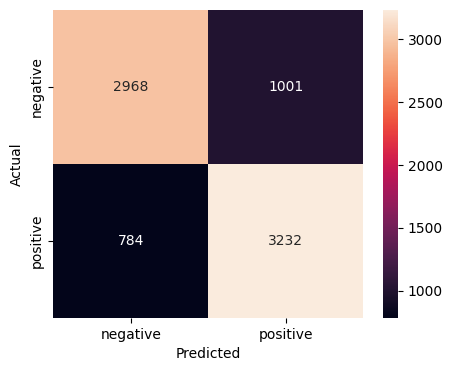

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

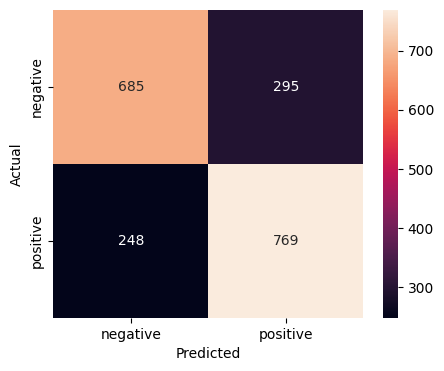

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

**Accuracy**

In [ ]:
train_accuracy_transformer_RF = accuracy_score(y_train,y_pred_train)
print("The accuracy on the training set is: ",train_accuracy_transformer_RF)
test_accuracy_transformer_RF = accuracy_score(y_test,y_pred_test)
print("The accuracy on the test set is: ",test_accuracy_transformer_RF)

The accuracy on the training set is:  0.7764558547276142
The accuracy on the test set is:  0.728092138207311


## **Sentiment Analysis with Neural Networks**

In [ ]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Model definition
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))  # 2 output classes

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since labels are integers
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,666 (225.26 KB)

 Trainable params: 57,666 (225.26 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fitting the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
    )

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7454 - loss: 0.5086 - val_accuracy: 0.7762 - val_loss: 0.4546
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8054 - loss: 0.4249 - val_accuracy: 0.7932 - val_loss: 0.4290
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8175 - loss: 0.4014 - val_accuracy: 0.8002 - val_loss: 0.4157
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8294 - loss: 0.3753 - val_accuracy: 0.8042 - val_loss: 0.4122
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8473 - loss: 0.3529 - val_accuracy: 0.8077 - val_loss: 0.4169
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8620 - loss: 0.3267 - val_accuracy: 0.8047 - val_loss: 0.4187
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8784 - loss: 0.2975 - val_accuracy: 0.7982 - val_loss: 0.4433
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8893 - loss: 0.2746 - val_accuracy: 0.

### **Checking Training and Test Performance**

In [ ]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


**Confusion Matrix**

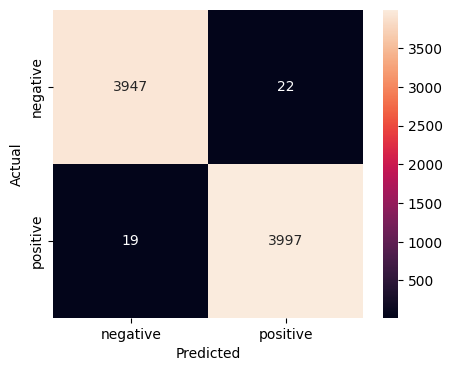

In [ ]:
plot_confusion_matrix(y_train, y_train_preds)

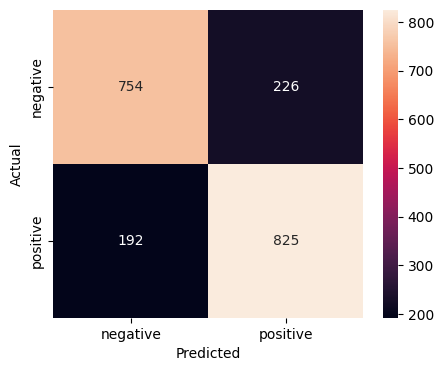

In [ ]:
plot_confusion_matrix(y_test, y_test_preds)

**Accuracy**

In [ ]:
train_accuracy_transformer_NN = accuracy_score(y_train,y_train_preds)
print("The accuracy on the training set is: ",train_accuracy_transformer_NN)
test_accuracy_transformer_NN = accuracy_score(y_test,y_test_preds)
print("The accuracy on the test set is: ",test_accuracy_transformer_NN)

The accuracy on the training set is:  0.9948653725735754
The accuracy on the test set is:  0.7906860290435653


# **Model Perfomance Comparison**

In [ ]:
# Create a dictionary to compare different models and their accuracies
model_comp = {
    'Model': [
        'Word2Vec-RF',
        'Sentence-Transformer-RF',
        'Word2Vec-NN',
        'Sentence-Transformer-NN'
    ],
    'Train Accuracy': [
        train_accuracy_Word2Vec_RF,
        train_accuracy_transformer_RF,
        train_accuracy_Word2Vec_NN,
        train_accuracy_transformer_NN
    ],
    'Test Accuracy': [
        test_accuracy_Word2Vec_RF,
        test_accuracy_transformer_RF,
        test_accuracy_Word2Vec_NN,
        test_accuracy_transformer_NN
    ]
}

# Creating the DataFrame
model_comp_df = pd.DataFrame(model_comp)

model_comp_df

,Model,Train Accuracy,Test Accuracy
0,Word2Vec-RF,0.661991,0.640961
1,Sentence-Transformer-RF,0.776456,0.728092
2,Word2Vec-NN,0.743143,0.733100
3,Sentence-Transformer-NN,0.994865,0.790686


**Important Note**
<br>
- Numbers can vary due to the random elements in model training and the complex nature of the techniques used.
-This includes differences in how data is processed and slight variations each time the model runs, leading to changes in performance results.

<font size=5>Observations</font>

### Observation

* **Word2Vec + Random Forest (Word2Vec-RF):** Shows low training and testing accuracy, indicating **underfitting** and limited ability to capture complex sentiment patterns.
* **Sentence Transformer + Random Forest:** Performs better than Word2Vec-RF and **generalizes better** to unseen test data.
* **Word2Vec + Neural Network:** Shows improved training and testing accuracy, indicating **less underfitting** than Word2Vec-RF.
* **Sentence Transformer + Neural Network:** Shows a noticeable difference between training and testing accuracy, indicating **potential overfitting**.
* Overall, **Sentence Transformer embeddings perform better than Word2Vec embeddings**, while the choice of classifier affects the level of underfitting or overfitting.


# **Conclusion**

- We created embeddings for the text data using the following methods:
    - Word2Vec
    - Sentence transformer

- We then built ML and DL models using the different datasets obtained from the different embedding techniques.
- We compared the performances of all the models we built.

<font size=5 color='blue'>Power Ahead!</font>
___